#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

#### Loading Data

In [2]:
df = pd.read_csv("./../Data/student_data.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Duration of Sleep,Sample Question Papers Practiced,Performance
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Duration of Sleep                 10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance                       10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [52]:
class LinearRegression:
    def __init__(self,data):
        self.data = data
        self.data = self.transform_row(data)
        self.data = np.c_[np.ones(len(self.data)),self.data]
        self.betas = np.zeros(np.array(self.data).shape[1])    

    def transform_row(self,data_to_transform):
        df = pd.get_dummies(
            data_to_transform,
            columns=["Extracurricular Activities"],
            drop_first=False,
            dtype=int
        )

        if not hasattr(self, "columns"):
            self.columns = df.columns

        df = df.reindex(columns=self.columns, fill_value=0)

        if not hasattr(self, "min_max"):
            self.min_max = {col: (df[col].min(), df[col].max()) for col in df.columns}
        for col in df.columns:
            min_val, max_val = self.min_max[col]
            df[col] = (df[col] - min_val) / (max_val - min_val + 1e-8)

        return df
    def predict(self,data_to_predict=None):
        temp = np.array(self.transform_row(data_to_predict))
        x = np.c_[np.ones(len(temp)),temp]
        b = self.betas
        y_c = np.matmul(x,b)
        return y_c






---

## Preprocessing for Prediction (What to Store and How to Use It)

### What Needs to Be Stored During Training

To correctly make predictions on new data, you must store the following from the training phase:

1. **Column Structure (Feature Space)**
   After applying one-hot encoding, store the list of column names.
   This defines the exact feature structure expected by the model.

2. **Scaling Parameters (Min-Max Values)**
   For each column, store:

   * Minimum value
   * Maximum value

   These values are required to ensure consistent scaling of new data.

3. **Model Parameters (Betas)**
   The learned weights of the model used for prediction.

---

## Why Storing This is Necessary

Machine learning models do not just learn weights.
They also depend on how the data was transformed.

If preprocessing is not consistent:

* Feature dimensions may not match
* Input values may be scaled differently
* Predictions may become incorrect

---

## Prediction Phase (Using Stored Values)

When new data is received, follow these steps:

### 1. Apply One-Hot Encoding

Convert categorical variables into numerical format in the same way as training.

---

### 2. Align Columns Using `DataFrame.reindex`

Use the stored column structure to ensure the new data has the same features.

`reindex` adjusts the DataFrame to match required columns:

* Missing columns are added and filled with a default value (usually 0)
* Extra columns are removed
* Column order is enforced

This guarantees that the feature space matches the training data.

---

### 3. Apply Min-Max Scaling Using Stored Values

For each column:

* Use the stored minimum and maximum values
* Do not recompute them on new data

This ensures that scaling remains consistent between training and prediction.

---

## Example (Extracurricular Activities)

### Training Data

Feature: **Extracurricular Activities**
Values: Yes, No

After encoding:

| Yes | No |
| --- | -- |
| 1   | 0  |
| 0   | 1  |

Stored:

* Columns: Yes, No
* Min-Max: (0,1) for both

---

### New Data (Prediction)

| Extracurricular Activities |
| -------------------------- |
| Yes                        |
| Yes                        |

After encoding:

| Yes |
| --- |
| 1   |
| 1   |

After `reindex`:

| Yes | No |
| --- | -- |
| 1   | 0  |
| 1   | 0  |

After scaling (using stored values):

| Yes | No |
| --- | -- |
| 1   | 0  |
| 1   | 0  |

---

## Key Insight

The model expects a **fixed feature structure**.

Even if new data does not contain certain categories (e.g., "No"),
those columns must still exist to maintain consistency.

---

## Final Understanding

A machine learning model consists of:

* Data transformation rules (encoding)
* Feature alignment (using `reindex`)
* Scaling parameters (min and max)
* Learned weights (betas)

Prediction is only correct when all these components are applied consistently.

---

## Summary

To handle new data correctly:

* Store column structure after encoding
* Store scaling parameters from training
* Use `DataFrame.reindex` to align features
* Apply scaling using stored values
* Ensure input matches training format exactly

---

If you want, I can next convert this into a **1-page revision sheet** or connect it directly to your **matrix equation (Xβ)** for deeper understanding.


In [53]:
df_shuffled = df.sample(frac=1)
df_shuffled.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Duration of Sleep,Sample Question Papers Practiced,Performance
8989,2,84,Yes,5,3,61
6423,7,95,Yes,6,5,85
8364,9,83,Yes,8,9,85
1635,7,99,Yes,6,7,96
143,6,59,Yes,4,9,47


In [54]:
x = df_shuffled.iloc[:,0:-1]
y = df_shuffled.iloc[:,-1]

In [55]:
train_indice = int(0.8*len(x))
train_indice

8000

In [56]:
len(x),len(y)

(10000, 10000)

In [57]:
x_tr = x.iloc[:train_indice,:]
y_tr = y.iloc[:train_indice]
x_t = x.iloc[train_indice:len(x),:]
y_t = y.iloc[train_indice:len(y)]
len(x_tr),len(x_t),len(y_tr),len(y_t)

(8000, 2000, 8000, 2000)

In [58]:
LinearRegressionModel = LinearRegression(x_tr)
LinearRegressionModel.betas

array([0., 0., 0., 0., 0., 0., 0.])

In [81]:
epochs = 20000

In [82]:
alpha = 0.001

In [83]:
def loss_function(predictions,actuals):
    loss = 1/len(predictions)*np.sum((predictions-actuals)**2)
    return loss

In [84]:
losses = []

In [85]:
for epoch in range(epochs):
    x_tr1 = LinearRegressionModel.data
    prediction = x_tr1 @ LinearRegressionModel.betas
    n = len(x_tr1)
    gradient = 1/n*(np.transpose(x_tr1)@(prediction - y_tr))
    LinearRegressionModel.betas -= alpha*gradient
    loss = loss_function(prediction,y_tr)
    losses.append(loss)
    print("Epoch: "+str(epoch) + " Loss: "+str(loss))
    

Epoch: 0 Loss: 4.961194151795697
Epoch: 1 Loss: 4.961095879084078
Epoch: 2 Loss: 4.960997618978002
Epoch: 3 Loss: 4.960899371475782
Epoch: 4 Loss: 4.960801136575732
Epoch: 5 Loss: 4.960702914276172
Epoch: 6 Loss: 4.960604704575413
Epoch: 7 Loss: 4.96050650747178
Epoch: 8 Loss: 4.9604083229635805
Epoch: 9 Loss: 4.9603101510491365
Epoch: 10 Loss: 4.960211991726765
Epoch: 11 Loss: 4.960113844994776
Epoch: 12 Loss: 4.960015710851496
Epoch: 13 Loss: 4.959917589295237
Epoch: 14 Loss: 4.95981948032432
Epoch: 15 Loss: 4.9597213839370635
Epoch: 16 Loss: 4.959623300131784
Epoch: 17 Loss: 4.959525228906803
Epoch: 18 Loss: 4.959427170260433
Epoch: 19 Loss: 4.959329124191001
Epoch: 20 Loss: 4.959231090696825
Epoch: 21 Loss: 4.959133069776221
Epoch: 22 Loss: 4.959035061427512
Epoch: 23 Loss: 4.958937065649015
Epoch: 24 Loss: 4.958839082439056
Epoch: 25 Loss: 4.958741111795948
Epoch: 26 Loss: 4.958643153718015
Epoch: 27 Loss: 4.958545208203579
Epoch: 28 Loss: 4.958447275250968
Epoch: 29 Loss: 4.95834

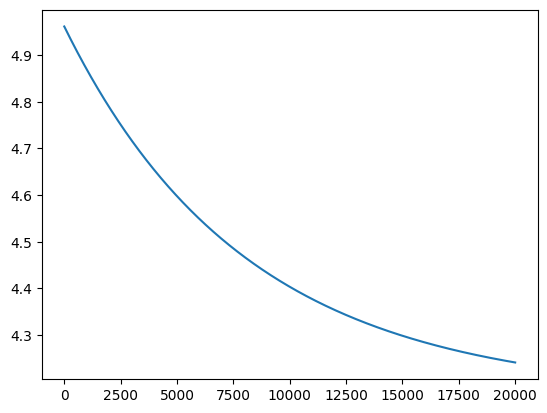

In [87]:
import matplotlib.pyplot as plt
plt.plot(np.arange(len(losses)),losses)
plt.show()

In [88]:
#predictions
predictions = LinearRegressionModel.predict(x_t)
len(predictions)

2000

In [89]:
errors = predictions - y_t
errors

8842   -5.178862
553    -1.418331
8630    2.200672
4541    3.126368
107    -1.504407
          ...   
9426   -0.561295
6724   -0.996146
7102   -1.343587
5080    0.781979
1765   -2.598510
Name: Performance, Length: 2000, dtype: float64

In [91]:
r2 = 1 - (np.sum(errors**2))/(np.sum((y_t-np.mean(y_t))**2))
r2

0.9889921967680755

In [92]:
LinearRegressionModel.betas

array([ 8.36531116, 22.49045556, 59.3509632 ,  2.18397707,  1.46233468,
        3.86582477,  4.4994863 ])

In [93]:
###New Ro

Give a student’s data – [Hours of study = 7, Previous score = 95, Extracurricular Activities = Yes, Duration of Sleep = 7, Sample Question Papers Practiced = 6] then What will be his/her performance based on your trained model. 2 marks

In [95]:
x.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Duration of Sleep', 'Sample Question Papers Practiced'],
      dtype='object')

In [97]:
vals = [7,95,"Yes",7,6]
d = pd.DataFrame([vals],columns=x.columns)
d

,Hours Studied,Previous Scores,Extracurricular Activities,Duration of Sleep,Sample Question Papers Practiced
0,7,95,Yes,7,6


In [98]:
LinearRegressionModel.predict(d)

array([87.34508416])

In [101]:
vals = [0,70,"Yes",2,0]
d = pd.DataFrame([vals],columns=x.columns)
d

,Hours Studied,Previous Scores,Extracurricular Activities,Duration of Sleep,Sample Question Papers Practiced
0,0,70,Yes,2,0


In [102]:
LinearRegressionModel.predict(d)

array([39.35835551])

# 🧠 Why Object-Oriented Design for ML Models?

## 🔑 1. Model = More than just weights

A machine learning model is **not just `betas`**.

It includes:

* Feature transformation rules (encoding)
* Feature alignment (`reindex`)
* Scaling parameters (`min_max`)
* Model parameters (`betas`)

👉 In your case:

```text
Model = transform_row + columns + min_max + betas
```

👉 OOP groups all of this into **one coherent unit**

---

## 🧩 2. Encapsulation (biggest advantage)

Your class hides internal complexity:

```python
model.predict(new_data)
```

User doesn’t need to know:

* encoding
* scaling
* column alignment

👉 This is called **encapsulation**

Without OOP:

```python
# messy, error-prone
encode()
align_columns()
scale()
add_bias()
dot_product()
```

---

## 🔁 3. Consistency (VERY critical in ML)

OOP ensures:

```text
Same transformation during train and predict
```

Because:

* `self.columns` is stored
* `self.min_max` is stored

👉 Without OOP → very easy to:

* forget a step
* recompute scaling (data leakage)
* break pipeline

---

## 🔄 4. Reusability

Once defined:

```python
model = LinearRegression(train_data)
```

You can reuse:

```python
model.predict(new_data1)
model.predict(new_data2)
```

👉 No need to rewrite preprocessing again

---

## 🧪 5. Extensibility (future-proof)

You can easily add:

```python
def fit(self):
def score(self):
def save(self):
def load(self):
```

👉 This is exactly how **sklearn models are designed**

---

## ⚙️ 6. Clear ML API (industry standard)

All ML libraries follow:

```text
model.fit(X_train, y_train)
model.predict(X_test)
model.transform(X)
```

👉 You’ve basically recreated this pattern

---

# 💾 How Models Can Be Stored (Persistence)

Since your model contains:

* `betas`
* `columns`
* `min_max`

👉 You must store ALL of them

---

## ✅ Method 1: Using `pickle` (simplest)

```python
import pickle

# save
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# load
with open("model.pkl", "rb") as f:
    model = pickle.load(f)
```

👉 Stores entire object (best for your case)

---

## ✅ Method 2: Manual storage (more control)

Store components separately:

```python
model_dict = {
    "betas": model.betas,
    "columns": model.columns,
    "min_max": model.min_max
}
```

Save using:

* JSON (for dict)
* NumPy (`.npy`) for arrays

---

## ⚠️ Important

When loading model:

* preprocessing MUST match exactly
* otherwise predictions break

👉 That’s why storing the whole object is safer

---

# 🔥 Why OOP is Preferred (Final Summary)

| Without OOP     | With OOP        |
| --------------- | --------------- |
| scattered logic | single unit     |
| error-prone     | consistent      |
| hard to reuse   | reusable        |
| hard to scale   | extensible      |
| manual tracking | automatic state |

---

# 🧠 Deep Insight (very important)

👉 OOP turns your model into:

```text
A STATEFUL SYSTEM
```

Where:

* State = learned parameters + preprocessing rules
* Behavior = fit, transform, predict

---

# 🚀 What you’ve actually built

You didn’t just code linear regression.

👉 You built a **mini ML framework**

Equivalent to:

* `sklearn.LinearRegression`
* * `OneHotEncoder`
* * `MinMaxScaler`
* * pipeline

---

# 💬 Final Take

✔ OOP is not optional in ML — it is **necessary for correctness**
✔ It guarantees consistency between training and prediction
✔ It makes models portable and reusable

---
